# Detect Pigeons by Fine Tuning MobilenetV2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/marbetschar/pigeon-detector/blob/master/mobilenet_v2.ipynb)

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import models, transforms
from dataset.torch import PigeonBBoxDataset

# Assuming your PigeonBBoxDataset class is already defined and imported

############################
# 1. Transforms & Dataset  #
############################

# ImageNet-style transforms (good for MobileNetV2)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # MobileNetV2 default input size
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet mean
        std=[0.229, 0.224, 0.225],   # ImageNet std
    ),
])

json_path = "dataset/labels.json"
images_root = "dataset/images"

full_dataset = PigeonBBoxDataset(
    json_path=json_path,
    images_root=images_root,
    transform=train_transform,
    normalize_bboxes=True,
)

#####################################
# 2. Train/Val Split & DataLoaders  #
#####################################

val_ratio = 0.2
n_total = len(full_dataset)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [n_train, n_val], generator=generator)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

#########################
# 3. Model & Criterion  #
#########################

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")

# Load pretrained MobileNetV2
mobilenet = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Replace the classifier head to output 4 bbox values [x, y, w, h]
in_features = mobilenet.classifier[-1].in_features
mobilenet.classifier[-1] = nn.Sequential(
    nn.Linear(in_features, 4),
    nn.Sigmoid(),  # maps outputs to (0,1)
)

mobilenet = mobilenet.to(device)

# Freeze all but the classifier:
for param in mobilenet.features.parameters():
    param.requires_grad = False

criterion = nn.MSELoss() # or nn.SmoothL1Loss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, mobilenet.parameters()),
    lr=1e-4,
)

###########################
# 4. Training + Val Loop  #
###########################

num_epochs = 10  # adjust as needed
best_val_loss = float("inf")
save_path = "models/mobilenet_v2.pth"

for epoch in range(num_epochs):
    mobilenet.train()
    running_loss = 0.0

    mobilenet.train()
    running_train_loss = 0.0

    for images, bboxes in train_loader:
        images = images.to(device)
        bboxes = bboxes.to(device)  # normalized [B,4] in [0,1]

        optimizer.zero_grad()

        outputs = mobilenet(images)  # normalized preds [B,4] in (0,1)
        loss = criterion(outputs, bboxes)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * images.size(0)

    epoch_train_loss = running_train_loss / len(train_dataset)

    #################
    # Val phase     #
    #################
    mobilenet.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, bboxes in val_loader:
            images = images.to(device)
            bboxes = bboxes.to(device)  # normalized GT

            outputs = mobilenet(images)  # normalized predictions
            loss = criterion(outputs, bboxes)

            running_val_loss += loss.item() * images.size(0)

    epoch_val_loss = running_val_loss / len(val_dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {epoch_train_loss:.4f} - Val Loss: {epoch_val_loss:.4f}")

    # Save best model based on val loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(mobilenet.state_dict(), save_path)
        print(f"  ✔ New best model saved with val loss {best_val_loss:.4f} to '{save_path}'")

/Users/marbetschar/Development/marbetschar/pigeon-detector/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch [1/10] - Train Loss: 0.1299 - Val Loss: 0.0981
  ✔ New best model saved with val loss 0.0981 to 'models/mobilenet_v2.pth'
Epoch [2/10] - Train Loss: 0.0875 - Val Loss: 0.0710
  ✔ New best model saved with val loss 0.0710 to 'models/mobilenet_v2.pth'
Epoch [3/10] - Train Loss: 0.0583 - Val Loss: 0.0474
  ✔ New best model saved with val loss 0.0474 to 'models/mobilenet_v2.pth'
Epoch [4/10] - Train Loss: 0.0393 - Val Loss: 0.0326
  ✔ New best model saved with val loss 0.0326 to 'models/mobilenet_v2.pth'
Epoch [5/10] - Train Loss: 0.0291 - Val Loss: 0.0238
  ✔ New best model saved with val loss 0.0238 to 'models/mobilenet_v2.pth'
Epoch [6/10] - Train Loss: 0.0220 - Val Loss: 0.0186
  ✔ New best model saved with val loss 0.0186 to 'models/mobilenet_v2.pth'
Epoch [7/10] - Train Loss: 0.0183 - Val Loss: 0.0156
  ✔ New best model saved with val loss 0.0156 to 'models/mobilenet_v2.pth'
Epoch [8/10] - Train Loss: 0.0169 - Val Loss: 0.0137
  ✔ New best model saved with val loss 0.0137 to 'm

In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ImageNet normalization params (same as used in transforms)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def denormalize_image(tensor):
    """
    tensor: (3, H, W), normalized
    returns: (H, W, 3) numpy array in [0, 1]
    """
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = tensor * std + mean
    img = img.clamp(0.0, 1.0)
    img = img.permute(1, 2, 0)  # (H, W, C)
    return img.cpu().numpy()

def visualize_prediction(model, dataset, idx, device, ax):
    """
    model: trained MobileNetV2 bbox regressor
    dataset: e.g. val_dataset
    idx: index in the dataset to visualize
    device: torch.device
    """
    model.eval()

    # Get sample
    img_tensor, gt_bbox = dataset[idx]  # img: (3,H,W) tensor, gt_bbox: (4,) tensor
    gt_bbox = gt_bbox.numpy()

    # Model prediction
    with torch.no_grad():
        input_tensor = img_tensor.unsqueeze(0).to(device)  # add batch dim
        pred_bbox = model(input_tensor)[0].cpu().numpy()   # (4,)

    # Denormalize image for plotting
    img_np = denormalize_image(img_tensor)
    H, W = img_np.shape[:2]

    # Un-normalize: [0,1] -> pixel coords
    gx, gy, gw, gh = gt_bbox
    gx, gy, gw, gh = gx * W, gy * H, gw * W, gh * H

    px, py, pw, ph = pred_bbox
    px, py, pw, ph = px * W, py * H, pw * W, ph * H

    ax.imshow(img_np)

    # Ground truth bbox
    rect_gt = plt.Rectangle(
        (gx, gy), gw, gh,
        linewidth=2,
        edgecolor='g',
        facecolor='none',
        label='GT'
    )
    ax.add_patch(rect_gt)

    # Predicted bbox
    rect_pred = plt.Rectangle(
        (px, py), pw, ph,
        linewidth=2,
        edgecolor='r',
        facecolor='none',
        label='Pred'
    )
    ax.add_patch(rect_pred)

    ax.legend()
    ax.set_axis_off()

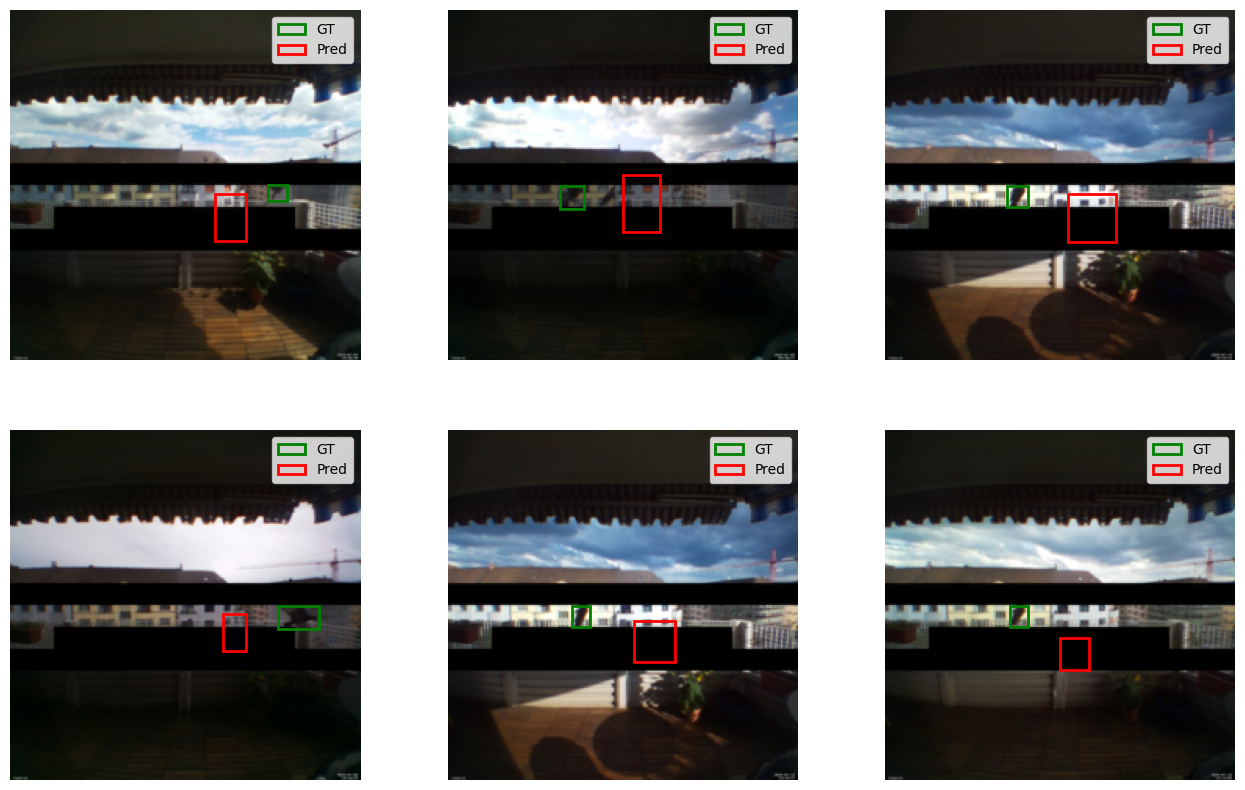

In [25]:
plt.figure(figsize=(16, 10))
for i in range(6):
    ax = plt.subplot(2, 3, i+1)
    idx = np.random.randint(len(train_dataset))
    visualize_prediction(mobilenet, train_dataset, idx=idx, device=device, ax=ax)